In [ ]:
# Load the dataset in

In [1]:
import scanpy as sc

adata = sc.read_h5ad(
    r"D:\aer\GSE159677_processed_final.h5ad"
)

adata

AnnData object with n_obs × n_vars = 47377 × 2000
    obs: 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
# Check adata.raw is still present

In [2]:
adata.raw

In [3]:
print(adata.raw)

Raw AnnData with n_obs × n_vars = 47377 × 33538


In [ ]:
# Creat Annotation object

In [4]:
adata_ct = adata.raw.to_adata()

adata_ct

AnnData object with n_obs × n_vars = 47377 × 33538
    obs: 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'
    uns: 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
# Save the annotation Object

In [5]:
adata_ct.write(
    r"D:\aer\GSE159677_ct.h5ad"
)

In [ ]:
# Verify the saved Object

In [6]:
adata_ct = sc.read_h5ad(
    r"D:\aer\GSE159677_ct.h5ad"
)

adata_ct

AnnData object with n_obs × n_vars = 47377 × 33538
    obs: 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'
    uns: 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
# Verift the Celltypist model, adult_human_vascular model is still present

In [7]:
from celltypist import models

vascular_model = models.Model.load(
    model="Adult_Human_Vascular.pkl"
)

print(vascular_model)

D:\Anaconda_redo\Lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


CellTypist model with 42 cell types and 3521 features
    date: 2024-12-19 16:51:45.315630
    details: vascular populations combined from multiple adult human organs
    source: https://doi.org/10.1038/s41591-024-03376-x
    version: v1
    cell types: adip_cap_ec, aerocyte_ec, ..., ven_smc
    features: SAMD11, HES4, ..., MT-CYB


In [ ]:
# Quick check gene names are present

In [8]:
print(adata_ct.var_names[:10])

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.4', 'AL732372.1', 'OR4F29', 'AC114498.1'],
      dtype='object')


In [ ]:
# Verify names of instructuions in celltypist

"""
The next three blocks of code are to make sure the right terms are being used for my version.

The example chat gave me,
from celltypist import celltypist

predictions = celltypist.annotate(
    adata = adata_ct,
    model = vascular_model,
    majority_voting = True, # Improves probustness
    over_clustering = True, # Helps distinguish similar cell types
    over_clustering_maximum_clusters = 200 # Prevents excessive splitting
    return_probabilities = True, # Returns full probability matrix
    verbose = True
)
"""

In [9]:
import inspect
from celltypist import celltypist

print(inspect.signature(celltypist.annotate))

ImportError: cannot import name 'celltypist' from 'celltypist' (D:\Anaconda_redo\Lib\site-packages\celltypist\__init__.py)

In [10]:
import inspect
import celltypist

print(inspect.signature(celltypist.annotate))

(filename: Union[anndata._core.anndata.AnnData, str] = '', model: Union[str, celltypist.models.Model, NoneType] = None, transpose_input: bool = False, gene_file: Optional[str] = None, cell_file: Optional[str] = None, mode: str = 'best match', p_thres: float = 0.5, majority_voting: bool = False, over_clustering: Union[str, list, tuple, numpy.ndarray, pandas.core.series.Series, pandas.core.indexes.base.Index, NoneType] = None, use_GPU: bool = False, min_prop: float = 0) -> celltypist.classifier.AnnotationResult


In [11]:
import inspect
from celltypist import annotate

print(inspect.signature(annotate))

(filename: Union[anndata._core.anndata.AnnData, str] = '', model: Union[str, celltypist.models.Model, NoneType] = None, transpose_input: bool = False, gene_file: Optional[str] = None, cell_file: Optional[str] = None, mode: str = 'best match', p_thres: float = 0.5, majority_voting: bool = False, over_clustering: Union[str, list, tuple, numpy.ndarray, pandas.core.series.Series, pandas.core.indexes.base.Index, NoneType] = None, use_GPU: bool = False, min_prop: float = 0) -> celltypist.classifier.AnnotationResult


In [ ]:
# Running the classifier on the dataset

In [12]:
import celltypist

predictions = celltypist.annotate(
    filename=adata_ct,
    model=vascular_model,
    majority_voting=True,
    over_clustering=True
)

🔬 Input data has 47377 cells and 33538 genes
🔗 Matching reference genes in the model
🧬 3521 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


TypeError: object of type 'bool' has no len()

In [ ]:
# Run classifer without majority voting

"""
This migh be better anyway, as majority voting can wipe away transitions state cells.
"""

In [13]:
predictions = celltypist.annotate(
    filename=adata_ct,
    model=vascular_model
)

🔬 Input data has 47377 cells and 33538 genes
🔗 Matching reference genes in the model
🧬 3521 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


In [ ]:
# Check classifier ran

In [14]:
print(type(predictions))

<class 'celltypist.classifier.AnnotationResult'>


In [ ]:
# Version

In [15]:
dir(predictions)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'adata',
 'cell_count',
 'decision_matrix',
 'predicted_labels',
 'probability_matrix',
 'summary_frequency',
 'to_adata',
 'to_plots',
 'to_table']

In [ ]:
# See Predictions

In [16]:
predictions

CellTypist prediction result for 47377 query cells
    predicted_labels: data frame with 1 column ('predicted_labels')
    decision_matrix: data frame with 47377 query cells and 42 cell types
    probability_matrix: data frame with 47377 query cells and 42 cell types
    adata: AnnData object referred

In [ ]:
# Inspect the predicted labels

In [17]:
predictions.predicted_labels.head()

,predicted_labels
AAACCCAAGATTAGAC-1-GSM4837523_DIS,kidney_cap_ec
AAACCCAAGCATGTTC-1-GSM4837523_DIS,littoral_EC
AAACCCAAGCCTGTCG-1-GSM4837523_DIS,kidney_cap_ec
AAACCCAAGGGTTTCT-1-GSM4837523_DIS,cap_lec
AAACCCAAGTGCACCC-1-GSM4837523_DIS,kidney_cap_ec


In [ ]:
# How many cells where assigned to each vascular population

In [18]:
predictions.predicted_labels.value_counts()

predicted_labels        
kidney_cap_ec               18217
littoral_EC                  8994
aorta_coronary_smc           5956
ven_ec_1                     1789
art_smc                      1640
brain_art_smc                1413
art_ec_2                     1200
aorta_coronary_ec            1114
cap_pc                       1097
cap_ec                        871
myo_cap_ec                    615
endometrium_cap_ec            613
uterine_pc                    602
smc_pc_intermediate           407
cap_lec                       393
ven_ec_2                      331
pul_ven_ec                    302
pericentral_cap_ec            278
floor_lec                     252
art_ec_1                      244
perifollicular_sinus_lec      220
glomeruli_ec                  146
adip_cap_ec                   127
pul_tip_cap_ec                112
pul_cap_ec                    111
ven_smc                       104
pul_smc                        77
bridging_lec                   37
aerocyte_ec            

In [ ]:
# Notes on kidney results

"""
The vascular model was trained on vascular cells collected from many organs,
among the reference population, this cell most closely resembles the
endothelial cells that were isolated from kideny capillaries.

Similar logic to other machine learning software.
It's assigns the cell type to the closest one it resembles.
"""

In [ ]:
# Convert the predicted labels to the AnnData object

In [19]:
adata_ct.obs["cell_type"] = predictions.predicted_labels["predicted_labels"]

In [ ]:
# Verify it worked

In [20]:
adata_ct.obs["cell_type"].value_counts().head()

cell_type
kidney_cap_ec         18217
littoral_EC            8994
aorta_coronary_smc     5956
ven_ec_1               1789
art_smc                1640
Name: count, dtype: int64

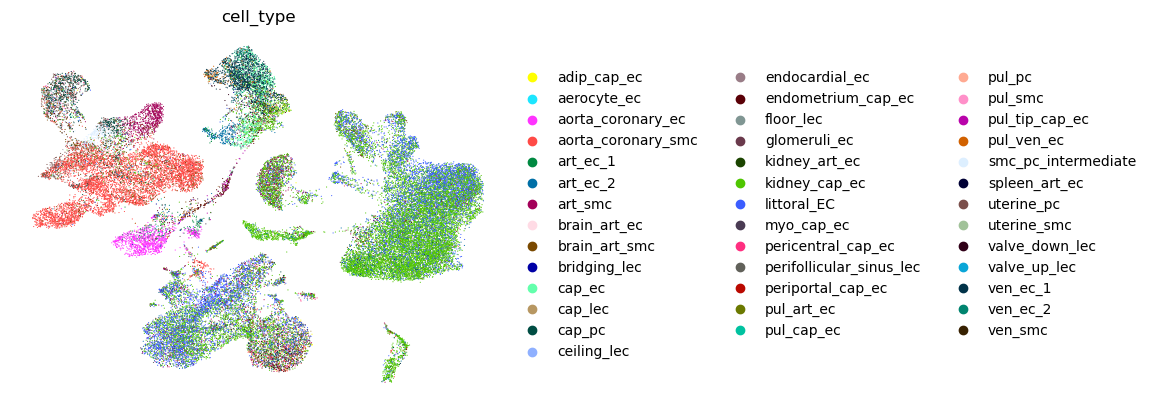

In [21]:
sc.pl.umap(
    adata_ct,
    color="cell_type",
    legend_loc="right margin",
    frameon=False
)

In [22]:
import pandas as pd

pd.crosstab(
    adata_ct.obs["leiden"],
    adata_ct.obs["cell_type"]
)

cell_type,adip_cap_ec,aerocyte_ec,aorta_coronary_ec,aorta_coronary_smc,art_ec_1,art_ec_2,art_smc,brain_art_ec,brain_art_smc,bridging_lec,...,pul_ven_ec,smc_pc_intermediate,spleen_art_ec,uterine_pc,uterine_smc,valve_down_lec,valve_up_lec,ven_ec_1,ven_ec_2,ven_smc
leiden,,,,,,,,,,,,,,,,,,,,,
0,5,1,0,6,2,380,99,0,96,11,...,2,0,0,3,0,0,0,8,0,0
1,1,0,0,0,0,141,95,0,32,1,...,0,0,0,1,0,0,0,5,0,0
2,1,1,1,3591,6,17,40,0,398,0,...,1,3,0,41,0,0,0,7,1,3
3,29,0,0,5,9,207,17,0,29,7,...,228,2,4,1,0,8,1,1614,233,0
4,1,0,0,6,0,66,125,0,14,0,...,0,17,1,0,0,0,0,16,7,0
5,68,12,0,164,5,11,92,0,50,3,...,0,14,1,4,0,0,0,22,31,0
6,0,1,1,1034,6,7,648,0,254,1,...,3,306,0,354,2,0,0,11,0,3
7,0,5,0,10,4,22,93,0,152,0,...,0,5,2,0,0,0,0,14,49,0
8,14,0,0,6,1,43,282,0,42,0,...,0,0,1,1,0,0,0,17,2,0


In [ ]:
# Qiuck analysis

"""
Cluster 2, almost entirely smooth muscle Aorta coronary SMC(3591), Brain art SMC(398).
Cluster 13, composed of aorta coronary SMC(930), Brain artirial SMC(78).
Cluster 6 contains aorta_coronary_smc(1034), art_smc(648), brain_art_smc(254), smc_pc_intermediate(306), uteri_pc(354).
Cluster 3 has ven_ec_1(1614), ven_ec_2(233), pul_ven_ec(228).
Cluster 9; aorta_coronary_ec(973), art_ec_1(113).
"""

In [ ]:
# To visualize better, make a heatmap

In [23]:
for cluster in sorted(adata_ct.obs["leiden"].unique(), key=int):
    subset = adata_ct.obs.loc[adata_ct.obs["leiden"] == cluster, "cell_type"]
    print(f"Leiden {cluster}:")
    print(subset.value_counts().head(5))
    print()

Leiden 0:
cell_type
kidney_cap_ec    7188
littoral_EC      1721
art_ec_2          380
cap_pc            111
art_smc            99
Name: count, dtype: int64

Leiden 1:
cell_type
kidney_cap_ec    3112
littoral_EC      2200
art_ec_2          141
art_smc            95
brain_art_smc      32
Name: count, dtype: int64

Leiden 2:
cell_type
aorta_coronary_smc    3591
brain_art_smc          398
cap_pc                  97
kidney_cap_ec           63
uterine_pc              41
Name: count, dtype: int64

Leiden 3:
cell_type
ven_ec_1         1614
cap_ec            827
kidney_cap_ec     605
ven_ec_2          233
pul_ven_ec        228
Name: count, dtype: int64

Leiden 4:
cell_type
kidney_cap_ec    1632
littoral_EC      1608
myo_cap_ec        183
art_smc           125
art_ec_2           66
Name: count, dtype: int64

Leiden 5:
cell_type
kidney_cap_ec         970
littoral_EC           582
endometrium_cap_ec    238
myo_cap_ec            199
cap_pc                176
Name: count, dtype: int64

Leiden 6:
cel

In [ ]:
# Clusters of interest

"""
Cluster 6 means to be of greatest interest closely related mural identities, mixed SMC states.
Cluster 2's dominate lable is aorta_coronary_smc.
Cluster 13's dominate lable is aorta_coronary_smc.

This can be used to study SMCS.
"""

In [ ]:
# Search for SMCs markers.

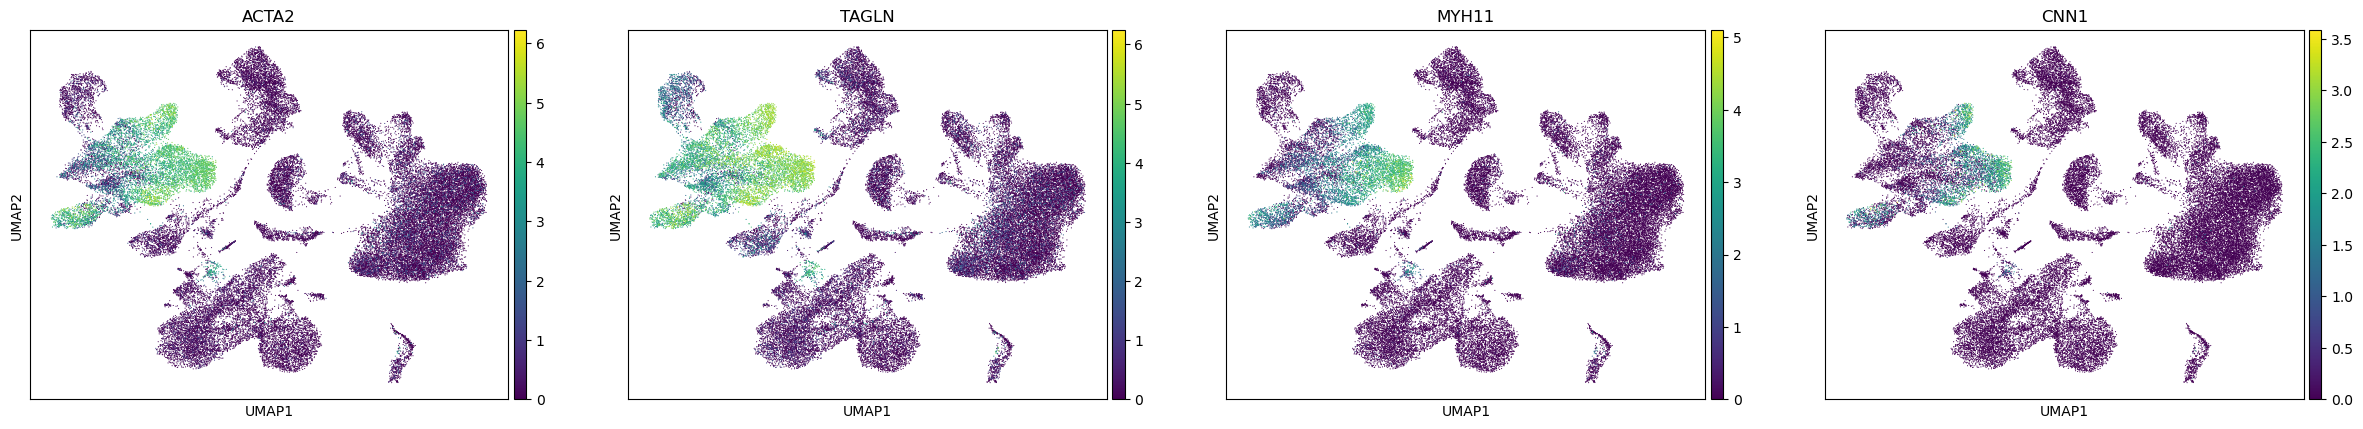

In [24]:
sc.pl.umap(
    adata_ct,
    color=[
        "ACTA2",
        "TAGLN",
        "MYH11",
        "CNN1"
    ],
    cmap="viridis",
    vmin=0
)

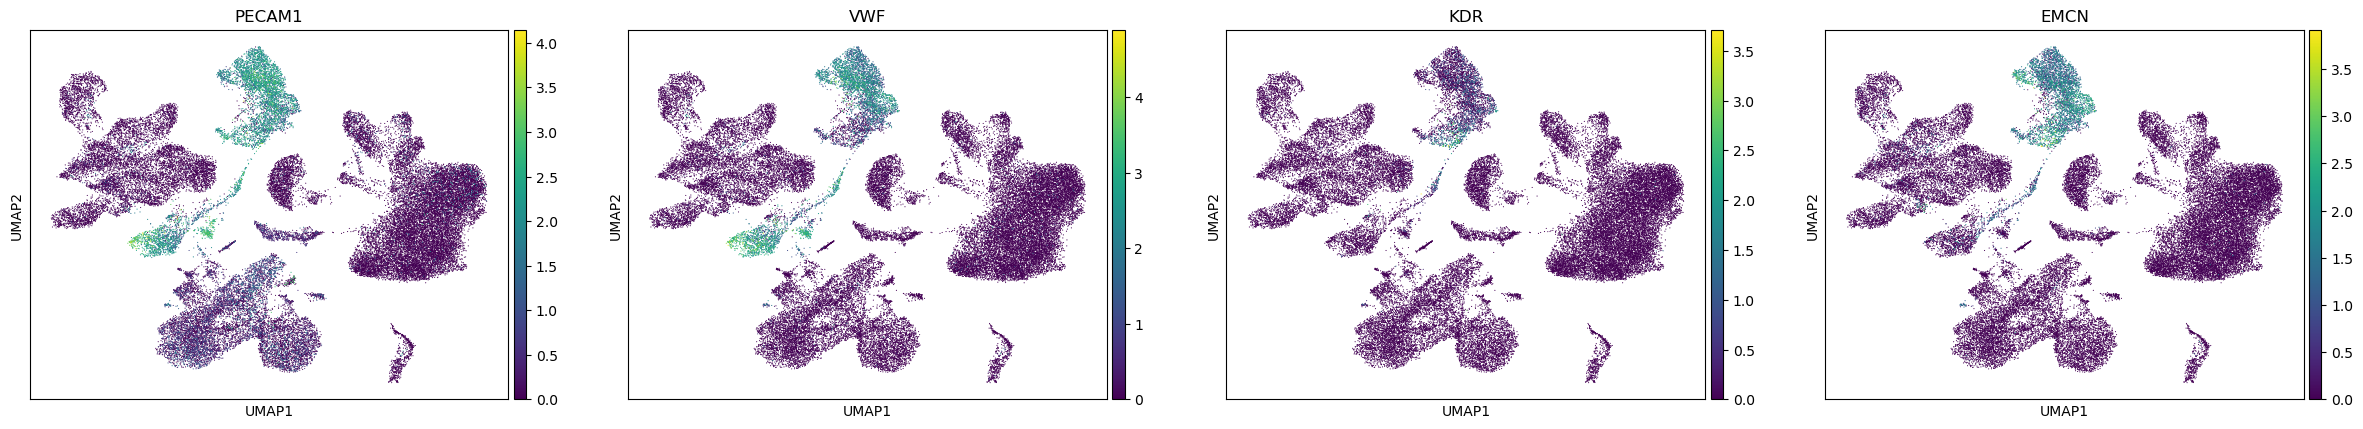

In [25]:
# Search for Endothelial markers

sc.pl.umap(
    adata_ct,
    color=[
        "PECAM1",
        "VWF",
        "KDR",
        "EMCN"
    ],
    cmap="viridis",
    vmin=0
)

In [ ]:
# Save annotated Vascular data

In [26]:
adata_ct.write(
    r"D:\aer\GSE159677_ct_vascular_annotated.h5ad"
)

In [ ]:
"""
Saving hre is mostly a precaution, since the next test is the immune low cells.
"""

In [ ]:
# Downloading the Immune All Low Model

In [27]:
from celltypist import models

models.download_models(
    force_update=False,
    model=["Immune_All_Low.pkl"]
)

📂 Storing models in C:\Users\scien\.celltypist\data\models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl


In [ ]:
# Load the Immmune All Low Model

In [28]:
immune_model = models.Model.load(
    model="Immune_All_Low.pkl"
)

print(immune_model)

CellTypist model with 98 cell types and 6639 features
    date: 2022-07-16 00:20:42.927778
    details: immune sub-populations combined from 20 tissues of 18 studies
    source: https://doi.org/10.1126/science.abl5197
    version: v2
    cell types: Age-associated B cells, Alveolar macrophages, ..., pDC precursor
    features: A1BG, A2M, ..., ZYX


In [ ]:
# Verify Immune All Low Model is present

In [29]:
print(immune_model)

CellTypist model with 98 cell types and 6639 features
    date: 2022-07-16 00:20:42.927778
    details: immune sub-populations combined from 20 tissues of 18 studies
    source: https://doi.org/10.1126/science.abl5197
    version: v2
    cell types: Age-associated B cells, Alveolar macrophages, ..., pDC precursor
    features: A1BG, A2M, ..., ZYX


In [ ]:
# Run the Immune Classifer on the current dataset

"""
Rather than, using a new dataset instead, will use the adata_ct.
This will allow us to see if the regions that are not vascular cells are immune cells.
"""

In [30]:
import celltypist

immune_predictions = celltypist.annotate(
    filename=adata_ct,
    model=immune_model
)

🔬 Input data has 47377 cells and 33538 genes
🔗 Matching reference genes in the model
🧬 5967 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


In [ ]:
# Now look at immune predictions

"""
Labled immune predictions as to not be confused with prediction which is,
for the vascular model.
"""

In [31]:
immune_predictions   # immune

CellTypist prediction result for 47377 query cells
    predicted_labels: data frame with 1 column ('predicted_labels')
    decision_matrix: data frame with 47377 query cells and 98 cell types
    probability_matrix: data frame with 47377 query cells and 98 cell types
    adata: AnnData object referred

In [ ]:
# View lables of prediction

In [32]:
immune_predictions.predicted_labels.head()

,predicted_labels
AAACCCAAGATTAGAC-1-GSM4837523_DIS,Macrophages
AAACCCAAGCATGTTC-1-GSM4837523_DIS,MAIT cells
AAACCCAAGCCTGTCG-1-GSM4837523_DIS,CD16- NK cells
AAACCCAAGGGTTTCT-1-GSM4837523_DIS,Non-classical monocytes
AAACCCAAGTGCACCC-1-GSM4837523_DIS,Intermediate macrophages


In [ ]:
# Get Cell count from Predictions

In [33]:
immune_predictions.predicted_labels.value_counts()

predicted_labels           
Tem/Trm cytotoxic T cells      7973
Endothelial cells              7164
Fibroblasts                    4616
Macrophages                    3545
Tem/Effector helper T cells    3503
                               ... 
Granulocytes                      1
MNP                               1
Mid erythroid                     1
Small pre-B cells                 1
gamma-delta T cells               1
Name: count, Length: 69, dtype: int64

In [ ]:
# Save the lables as AnnData

In [34]:
adata_ct.obs["immune_cell_type"] = (
    immune_predictions.predicted_labels["predicted_labels"]
)

In [ ]:
# Verify

In [35]:
adata_ct.obs["immune_cell_type"].value_counts().head()

immune_cell_type
Tem/Trm cytotoxic T cells      7973
Endothelial cells              7164
Fibroblasts                    4616
Macrophages                    3545
Tem/Effector helper T cells    3503
Name: count, dtype: int64

In [ ]:
# Plot the UMAP

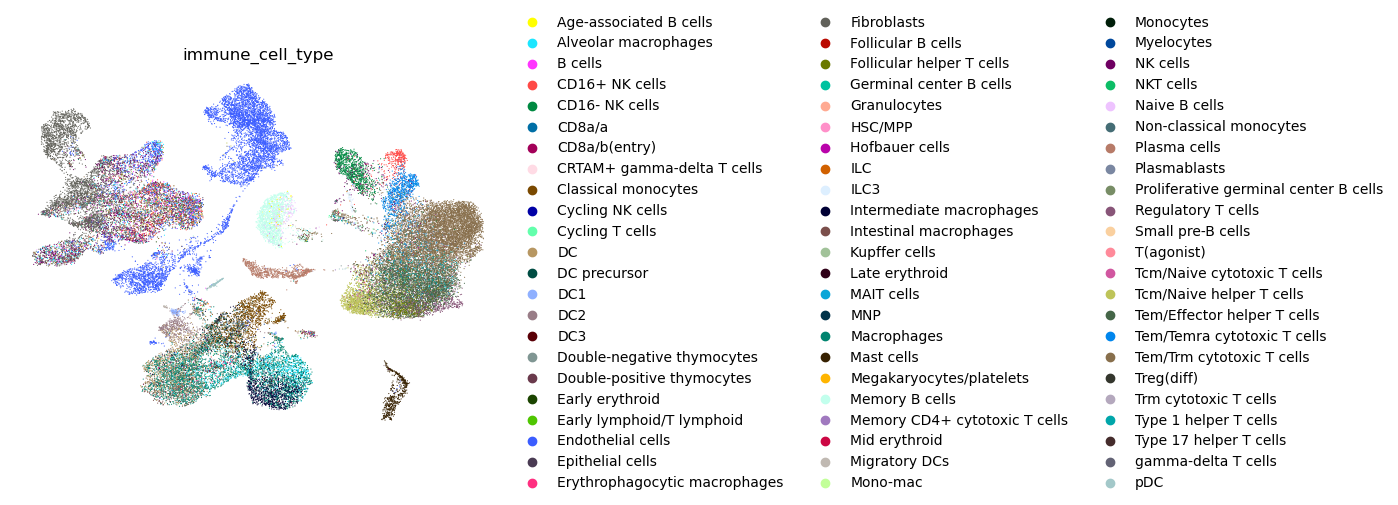

In [36]:
sc.pl.umap(
    adata_ct,
    color="immune_cell_type",
    legend_loc="right margin",
    frameon=False
)

In [ ]:
# Compare

In [ ]:
# Quick anlysis of UMAP for Immune_All_Low Model

"""
The electro blue regions is being labled Endothelial cells, which
where labled aorta coronary endothelial cells and cappilary endothelials cells
by the Vascular model.

The brownish gray is being labled fibroblasts which was the region the vascular 
model labled SMCs.

"""

In [37]:
pd.crosstab(
    adata_ct.obs["cell_type"],
    adata_ct.obs["immune_cell_type"]
)

immune_cell_type,Age-associated B cells,Alveolar macrophages,B cells,CD16+ NK cells,CD16- NK cells,CD8a/a,CD8a/b(entry),CRTAM+ gamma-delta T cells,Classical monocytes,Cycling NK cells,...,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,Treg(diff),Trm cytotoxic T cells,Type 1 helper T cells,Type 17 helper T cells,gamma-delta T cells,pDC
cell_type,,,,,,,,,,,,,,,,,,,,,
adip_cap_ec,2,25,0,1,1,0,0,0,0,0,...,1,0,2,3,0,0,2,0,0,0
aerocyte_ec,0,2,0,0,0,0,0,0,5,0,...,0,1,0,0,0,0,0,1,0,0
aorta_coronary_ec,0,1,1,0,0,0,0,0,2,0,...,0,1,0,2,0,0,0,0,0,0
aorta_coronary_smc,7,352,213,449,11,0,2,0,300,0,...,51,13,21,257,4,2,0,2,0,2
art_ec_1,1,3,1,0,0,0,0,0,3,0,...,0,2,0,3,0,0,0,0,0,0
art_ec_2,2,11,1,16,22,1,0,2,29,0,...,125,96,50,196,1,9,10,1,0,0
art_smc,16,87,27,28,11,0,0,1,64,0,...,23,16,7,187,0,3,5,2,0,5
brain_art_ec,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
brain_art_smc,2,69,19,81,80,1,0,0,156,0,...,57,34,8,75,1,1,3,1,0,16


In [ ]:
# Compare

In [38]:
import pandas as pd

pd.crosstab(
    adata_ct.obs["leiden"],
    adata_ct.obs["immune_cell_type"]
)

immune_cell_type,Age-associated B cells,Alveolar macrophages,B cells,CD16+ NK cells,CD16- NK cells,CD8a/a,CD8a/b(entry),CRTAM+ gamma-delta T cells,Classical monocytes,Cycling NK cells,...,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,Treg(diff),Trm cytotoxic T cells,Type 1 helper T cells,Type 17 helper T cells,gamma-delta T cells,pDC
leiden,,,,,,,,,,,,,,,,,,,,,
0,1,8,0,5,5,3,2,11,11,0,...,1522,3338,105,2228,2,97,509,70,0,0
1,0,1,1,6,22,0,1,40,0,0,...,6,63,170,4987,1,133,31,3,0,0
2,7,227,171,444,22,0,1,0,289,0,...,81,7,23,184,2,2,0,3,0,0
3,0,0,0,0,0,0,0,0,0,0,...,5,0,0,2,0,0,0,0,0,0
4,1,202,0,4,1,0,3,2,43,0,...,1,4,1,22,0,1,0,0,0,0
5,0,588,0,9,3,0,0,0,34,0,...,6,11,2,29,0,0,1,2,0,0
6,4,132,62,68,9,0,2,0,25,0,...,17,10,5,137,1,0,0,5,0,0
7,0,19,0,0,2,0,0,0,1320,0,...,7,3,2,20,1,2,0,0,0,0
8,54,1,10,1,1,0,0,1,0,0,...,0,20,0,47,0,1,2,0,0,0


In [ ]:
# Save Immune

In [39]:
adata_ct.write(
    r"D:\aer\GSE159677_ct_immune_low_annotated.h5ad"
)

In [ ]:
# This actually has both immune and vascular data
# I am actually going to delete this one, so later I don't think it's only immune.
# The version labled GSE159677_ct_immune_low_annotated.h5ad will be saved.

In [ ]:
# Check Immune saved

In [40]:
adata_ct = sc.read_h5ad(
    r"D:\aer\GSE159677_ct_immune_low_annotated.h5ad"
)

adata_ct

AnnData object with n_obs × n_vars = 47377 × 33538
    obs: 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'immune_cell_type'
    uns: 'cell_type_colors', 'condition_colors', 'hvg', 'immune_cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [41]:
adata_ct.obs.columns

Index(['sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type',
       'immune_cell_type'],
      dtype='object')

In [ ]:
# Make it clear that is have both immune and vascular data

In [42]:
adata_ct.write(
    r"D:\aer\GSE159677_ct_vascular_immune_annotated.h5ad"
)

In [ ]:
# check it saved

In [43]:
adata_ct = sc.read_h5ad(
    r"D:\aer\GSE159677_ct_immune_low_annotated.h5ad"
)

adata_ct

AnnData object with n_obs × n_vars = 47377 × 33538
    obs: 'sample', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'immune_cell_type'
    uns: 'cell_type_colors', 'condition_colors', 'hvg', 'immune_cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
# End of Cell Annotation

"""
This is the end of the cell annotation.
Next should be the SMCs state analysis.
"""